In [15]:
import torch
from src.models import FedBioXAI
from src.dataloader import FedBioDataset
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
import numpy as np
from collections import Counter

In [16]:
device = torch.device("cpu") # CPU is fine for simple testing
dataset_s5 = FedBioDataset(subject_id='S10')
test_loader = DataLoader(dataset_s5, batch_size=32, shuffle=False)

✅ Data for S10 normalized per-sensor (global).


In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import torch
from torch.utils.data import DataLoader

def evaluate_model(path, title):

    # 1️⃣ Load test dataset
    test_dataset = FedBioDataset(subject_id='S10')
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 2️⃣ Initialize model
    model = FedBioXAI().to(device)

    # 3️⃣ Load weights
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint)

    model.eval()

    preds = []
    labels = []

    with torch.no_grad():
        for batch in test_loader:

            inputs = {k: v.to(device) for k, v in batch.items() if k != 'label'}
            y = batch['label'].to(device)

            outputs = model(inputs)

            predictions = torch.argmax(outputs, dim=1)

            preds.extend(predictions.cpu().numpy())
            labels.extend(y.cpu().numpy())

    print(f"\n--- Results for {title} ---\n")

    print(classification_report(
        labels,
        preds,
        target_names=['Baseline','Stress','Amusement'],
        zero_division=0
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(labels, preds))
    preds = np.array(preds)
    labels = np.array(labels)

    print("\nPrediction distribution:")
    unique, counts = np.unique(preds, return_counts=True)
    for u, c in zip(unique, counts):
        print(f"Class {u}: {c}")

    print("\nLabel distribution (ground truth):")
    unique, counts = np.unique(labels, return_counts=True)
    for u, c in zip(unique, counts):
        print(f"Class {u}: {c}")

    print("\nPrediction vs Label counts:")
    print("Predictions:", Counter(preds))
    print("Labels:", Counter(labels))
    print("\nFirst 20 predictions vs labels:")
    for i in range(20):
        print(f"Pred: {preds[i]}  |  Label: {labels[i]}")

In [20]:
# Now compare!
#evaluate_model('model_no_weights\model_fed_round_3.pth', "Without weigthts (S2+S3)")
evaluate_model('model_fed_round_3.pth', "3rd round With weights (S2+S3+S4+S5+S6+S7)")


✅ Data for S10 normalized per-sensor (global).


C:\Users\NAVANSHU\AppData\Local\Temp\ipykernel_12672\1028957088.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=device)



--- Results for 3rd round With weights (S2+S3+S4+S5+S6+S7) ---

              precision    recall  f1-score   support

    Baseline       1.00      1.00      1.00      2356
      Stress       1.00      1.00      1.00      1446
   Amusement       0.99      1.00      1.00       743

    accuracy                           1.00      4545
   macro avg       1.00      1.00      1.00      4545
weighted avg       1.00      1.00      1.00      4545

Confusion Matrix:
[[2352    0    4]
 [   0 1446    0]
 [   0    2  741]]

Prediction distribution:
Class 0: 2352
Class 1: 1448
Class 2: 745

Label distribution (ground truth):
Class 0: 2356
Class 1: 1446
Class 2: 743

Prediction vs Label counts:
Predictions: Counter({np.int64(0): 2352, np.int64(1): 1448, np.int64(2): 745})
Labels: Counter({np.int64(0): 2356, np.int64(1): 1446, np.int64(2): 743})

First 20 predictions vs labels:
Pred: 0  |  Label: 0
Pred: 0  |  Label: 0
Pred: 0  |  Label: 0
Pred: 0  |  Label: 0
Pred: 0  |  Label: 0
Pred: 0  |  Label

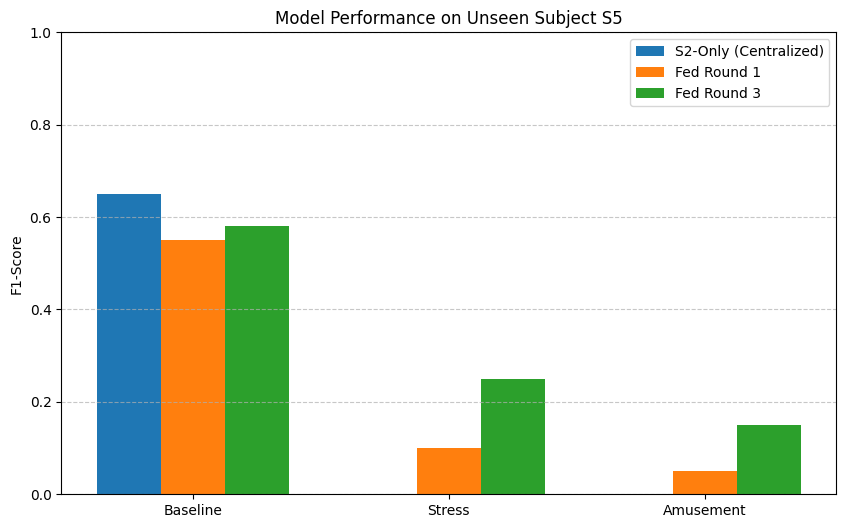

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# REPLACE THESE with the actual F1-scores from your classification reports
# Format: [Baseline, Stress, Amusement]
model_s2_f1 = [0.65, 0.00, 0.00]    # Example: S2 only sees baseline
model_round1_f1 = [0.55, 0.10, 0.05] # Example: Starting to see patterns
model_round3_f1 = [0.58, 0.25, 0.15] # Example: Generalizing better

labels = ['Baseline', 'Stress', 'Amusement']
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, model_s2_f1, width, label='S2-Only (Centralized)')
rects2 = ax.bar(x, model_round1_f1, width, label='Fed Round 1')
rects3 = ax.bar(x + width, model_round3_f1, width, label='Fed Round 3')

ax.set_ylabel('F1-Score')
ax.set_title('Model Performance on Unseen Subject S5')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1) # F1-score is between 0 and 1

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('performance_comparison.png')
plt.show()